In [1]:
# Cell 1: Environment Setup and Directory Configuration
import os
import pandas as pd
import matplotlib.pyplot as plt
import pypowsybl as pp
import pypowsybl.network as pn
from OMPython import OMCSessionZMQ

# --- Configuration ---
# MODEL_DIR: Directory containing the .mo files (Current Working Directory)
MODEL_DIR = os.getcwd() 

# OUTPUT_DIR: Directory where simulation results (CSV files) will be saved
OUTPUT_DIR = os.path.join(MODEL_DIR, "PyPowSyBl_approach_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"[INFO] Working Directory: {MODEL_DIR}")
print(f"[INFO] Output Directory: {OUTPUT_DIR}")

[INFO] Working Directory: /home/guiu/Projects/dynawo-notebooks/Model_and_Params
[INFO] Output Directory: /home/guiu/Projects/dynawo-notebooks/Model_and_Params/PyPowSyBl_approach_outputs


In [2]:
# Cell 2: Auxiliary Network Construction (PyPowSyBl)
def create_auxiliary_network(p_setpoint_mw, v_target_kv):
    """
    Creates a simple 2-bus network (Source -- Line -- BESS) to calculate the initial Power Flow.
    
    We use the 'one-by-one' creation method with Python lists to ensure strict type compatibility 
    with the underlying C++ IIDM engine, avoiding pandas object-type errors.
    """
    network = pn.create_empty()
    
    print("[INFO] Creating Voltage Levels...")
    # 1. Create Voltage Levels
    # Define two 110kV voltage levels connected by a breaker topology.
    network.create_voltage_levels(
        id=['VL_Source', 'VL_BESS'], 
        nominal_v=[110.0, 110.0], 
        topology_kind=['BUS_BREAKER', 'BUS_BREAKER']
    )
    
    print("[INFO] Creating Buses...")
    # 2. Create Buses
    # Physical nodes within the voltage levels.
    network.create_buses(
        id=['Bus_Source', 'Bus_BESS'], 
        voltage_level_id=['VL_Source', 'VL_BESS']
    )
    
    print("[INFO] Creating Line...")
    # 3. Create Line
    # Connecting the Source bus to the BESS bus.
    # Note: We explicitly set susceptances (b1, b2) and conductances (g1, g2) to 0.0
    # to satisfy strict IIDM schema validation.
    network.create_lines(
        id=['Line_1'], 
        voltage_level1_id=['VL_Source'], bus1_id=['Bus_Source'],
        voltage_level2_id=['VL_BESS'],   bus2_id=['Bus_BESS'],
        r=[0.0], x=[2.0], 
        g1=[0.0], b1=[0.0], g2=[0.0], b2=[0.0]
    )
    
    print("[INFO] Creating Generators...")
    
    # 4. Create Generators
    
    # Generator 1: Slack Generator (Infinite Source)
    # This represents the external grid. We set very wide P/Q limits (-9999 to 9999)
    # so it can absorb or inject any amount of power required to maintain voltage stability.
    # CRITICAL: Explicit min_q/max_q are required when voltage_regulator_on=True.
    network.create_generators(
        id=['Gen_Source'], 
        voltage_level_id=['VL_Source'], bus_id=['Bus_Source'],
        target_p=[0.0], 
        target_v=[110.0], 
        voltage_regulator_on=[True],
        min_p=[-9999.0], max_p=[9999.0],
    )
    
    # Generator 2: BESS (Battery Energy Storage System)
    # Modeled as a generator to establish the initial operating point (P setpoint, V target).
    network.create_generators(
        id=['Gen_BESS'], 
        voltage_level_id=['VL_BESS'], bus_id=['Bus_BESS'],
        target_p=[float(p_setpoint_mw)], 
        target_v=[float(v_target_kv)], 
        voltage_regulator_on=[True],
        min_p=[-100.0], max_p=[100.0],
    )
    
    return network

# --- Usage Example ---
# Define BESS base power (MVA) and target setpoint (0.5 pu = 3 MW)
bess_base_mva = 6.0
p_target_mw = 0.5 * bess_base_mva  
v_target_kv = 110.0

print(f"[INFO] Building Powsybl Network with P={p_target_mw} MW, V={v_target_kv} kV...")

try:
    static_network = create_auxiliary_network(p_target_mw, v_target_kv)
    print("[SUCCESS] Network created successfully.")
except Exception as e:
    print(f"[ERROR] Failed to create network: {e}")
    import traceback
    traceback.print_exc()

[INFO] Building Powsybl Network with P=3.0 MW, V=110.0 kV...
[INFO] Creating Voltage Levels...
[INFO] Creating Buses...
[INFO] Creating Line...
[INFO] Creating Generators...
[SUCCESS] Network created successfully.


In [3]:
# Cell 3: Loadflow Execution and Data Extraction
def get_loadflow_results(network, gen_id="Gen_BESS"):
    """
    Runs an AC Loadflow simulation and extracts the operating point (P, Q, V, Angle)
    for the specified generator.
    """
    # 1. Run AC Loadflow
    print("[INFO] Running AC Loadflow...")
    params = pp.loadflow.Parameters()
    results = pp.loadflow.run_ac(network, params)
    
    # Check Convergence Status
    # We cast status to string to ensure robustness across different PyPowSyBl versions.
    status = results[0].status
    print(f"[INFO] Loadflow Status: {status}")
    
    if str(status) != "CONVERGED":
        print(f"   [WARN] Loadflow did not fully converge. Status: {status}")
    
    # 2. Extract Data
    # The network object is updated in-place with the simulation results.
    gen_df = network.get_generators()
    bus_df = network.get_buses()
    
    try:
        # Retrieve Active (P) and Reactive (Q) power
        p_gen = gen_df.at[gen_id, 'p']
        q_gen = gen_df.at[gen_id, 'q']
        
        # Retrieve Voltage Magnitude and Angle from the connected bus
        bus_id = gen_df.at[gen_id, 'bus_id']
        v_mag = bus_df.at[bus_id, 'v_mag']
        angle_deg = bus_df.at[bus_id, 'v_angle']
        
        return {
            "P_MW": p_gen,
            "Q_MVAR": q_gen,
            "V_kV": v_mag,
            "Angle_deg": angle_deg
        }
    except KeyError as e:
        raise Exception(f"Could not find generator or bus in results: {e}")

# Execute Logic
try:
    lf_results = get_loadflow_results(static_network)

    print("\n[INFO] PyPowSyBl Loadflow Results:")
    for k, v in lf_results.items():
        print(f"   {k}: {v:.4f}")
        
except Exception as e:
    print(f"[ERROR] {e}")

[INFO] Running AC Loadflow...
[INFO] Loadflow Status: ComponentStatus.CONVERGED
   [WARN] Loadflow did not fully converge. Status: ComponentStatus.CONVERGED

[INFO] PyPowSyBl Loadflow Results:
   P_MW: -0.0000
   Q_MVAR: -0.0000
   V_kV: 110.0000
   Angle_deg: 0.0000


In [4]:
# Cell 4: OpenModelica Session Setup and Model Loading
# --- Configuration ---
# Path to the main Dynawo package file. Update this path if your installation differs.
DYNAWO_PKG_PATH = "/home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo"

# Start OpenModelica Session
omc = OMCSessionZMQ()

# Set the working directory for OpenModelica output files
omc.sendExpression(f'cd("{OUTPUT_DIR}")')

def load_models(omc_session, source_dir, dynawo_path):
    print(f"[INFO] 1. Loading Standard Libraries...")
    
    # 1. Load Modelica Standard Library (MSL)
    if not omc_session.sendExpression("loadModel(Modelica)"):
         print("   [WARN] Could not load 'Modelica'.")
    
    # 2. Load 'Complex' Library
    # IMPORTANT: This is required for Dynawo's AC math functions (e.g., ComplexMath.'abs').
    if not omc_session.sendExpression("loadModel(Complex)"):
         print("   [WARN] Could not load 'Complex'. Models utilizing AC math might fail.")
    else:
         print("   [OK] Loaded 'Complex' library.")

    # 3. Load ModelicaServices
    omc_session.sendExpression("loadModel(ModelicaServices)")

    print(f"[INFO] 2. Loading Dynawo Library from: {dynawo_path}")
    if not os.path.exists(dynawo_path):
        print(f"   [ERROR] Dynawo package.mo not found at: {dynawo_path}")
        return False
        
    # Load Dynawo Package
    if not omc_session.sendExpression(f'loadFile("{dynawo_path}")'):
        err = omc_session.sendExpression("getErrorString()")
        print(f"   [ERROR] Failed to load Dynawo: {err}")
        return False
    else:
        print("   [OK] Dynawo Library Loaded.")

    print(f"[INFO] 3. Loading Local Models from: {source_dir}")
    # Files must be loaded in specific order of dependency:
    # Components -> Initialization Blocks -> Static System -> Dynamic System
    files = [
        "BESScbCurrentSource.mo",
        "BESS_init.mo",
        "MyBESS_static.mo",
        "MyBESS.mo"
    ]
    
    for f in files:
        path = os.path.join(source_dir, f).replace("\\", "/") 
        if not os.path.exists(path):
             print(f"   [ERROR] Local file missing: {path}")
             return False
             
        # Load the local .mo file
        if not omc_session.sendExpression(f'loadFile("{path}")'):
            err = omc_session.sendExpression("getErrorString()")
            print(f"   [ERROR] Failed to load {f}: {err}")
            return False
        else:
            print(f"   [OK] Loaded {f}")
            
    return True

# Run Loading Sequence
try:
    if not load_models(omc, MODEL_DIR, DYNAWO_PKG_PATH):
        raise Exception("Failed to load Modelica models.")
    print("[SUCCESS] All models loaded correctly (including Complex lib).")
except Exception as e:
    print(e)

[INFO] 1. Loading Standard Libraries...
   [OK] Loaded 'Complex' library.
[INFO] 2. Loading Dynawo Library from: /home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo


[OMC log for 'sendExpression(loadFile("/home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo"), True)']: [grammar:warning:530] The package.order file does not list all .mo files and directories (containing package.mo) present in its directory.
Missing names are:
	BESScbCurrentSource
	MyBESS
	BESS_init
	StaticBESS
	MyBESS_static


   [OK] Dynawo Library Loaded.
[INFO] 3. Loading Local Models from: /home/guiu/Projects/dynawo-notebooks/Model_and_Params
   [OK] Loaded BESScbCurrentSource.mo
   [OK] Loaded BESS_init.mo
   [ERROR] Local file missing: /home/guiu/Projects/dynawo-notebooks/Model_and_Params/MyBESS_static.mo
Failed to load Modelica models.


In [5]:
# Cell 5: Static Initialization Bridge (Calculating Initial States)
def run_static_bridge(omc, pf_results, base_mva=6.0, nominal_v=110.0):
    """
    1. Sets parameters in the Static Model based on Loadflow results.
    2. Runs a short simulation to let the INIT block converge.
    3. Extracts the calculated internal states (Id0, Iq0).
    """
    # Define Fully Qualified Name (FQN) as the model is inside the Dynawo package structure
    model_fqn = "Dynawo.Examples.BESS.WECC.MyBESS_static"
    output_name = "MyBESS_static" 
    
    # 1. Convert physical values to Per Unit (PU)
    p_pu = pf_results["P_MW"] / base_mva
    v_pu = pf_results["V_kV"] / nominal_v
    angle_rad = pf_results["Angle_deg"] * (3.14159 / 180.0)
    
    print(f"\n[INFO] Bridge Params: P={p_pu:.4f}, V={v_pu:.4f}, Angle={angle_rad:.4f}")

    # 2. Set Parameters
    # We inject P, V, and Angle into the static generator and infinite bus.
    # Note: We do NOT set QGen0Pu because the PV generator calculates it automatically.
    params_to_set = [
        f"GenPV.PGen0Pu={p_pu}",
        f"GenPV.U0Pu={v_pu}",
        f"GenPV.UPhase={angle_rad}",
        f"infiniteBus.UPu={v_pu}", 
        f"infiniteBus.UPhase={angle_rad}"
    ]
    
    print(f"[INFO] Setting parameters on {model_fqn}...")
    for param in params_to_set:
        cmd = f"setParameterValue({model_fqn}, {param})"
        # Send parameter and check for errors
        if omc.sendExpression(cmd) is False:
             print(f"   [WARN] Failed to set {param}: {omc.sendExpression('getErrorString()')}")

    # 3. Simulate Static Case
    print(f"[INFO] Simulating {model_fqn}...")
    omc.sendExpression(f'cd("{OUTPUT_DIR}")')
    
    # We use fileNamePrefix to force a clean output filename
    sim_cmd = f"simulate({model_fqn}, stopTime=0.1, outputFormat=\"csv\", fileNamePrefix=\"{output_name}\")"
    sim_res = omc.sendExpression(sim_cmd)
    
    # Check for simulation failure
    if "Error" in str(omc.sendExpression("getErrorString()")):
        print(f"[FATAL ERROR] Simulation failed.")
        print(omc.sendExpression("getErrorString()"))
        return None

    # 4. Extract Calculated States
    res_file = os.path.join(OUTPUT_DIR, f"{output_name}_res.csv")
    if not os.path.exists(res_file):
        print(f"[ERROR] Result file missing: {res_file}")
        return None

    try:
        df = pd.read_csv(res_file)
        last_row = df.iloc[-1]
        
        # Dynamically find the columns for Id0Pu and Iq0Pu
        # Column names may vary due to flattening, so we search by substring.
        cols = df.columns.tolist()
        id0_col = next((c for c in cols if "bess_INIT" in c and "Id0Pu" in c), None)
        iq0_col = next((c for c in cols if "bess_INIT" in c and "Iq0Pu" in c), None)

        if id0_col and iq0_col:
            id0 = last_row[id0_col]
            iq0 = last_row[iq0_col]
            print(f"[SUCCESS] Calculated Init States: Id0Pu={id0:.5f}, Iq0Pu={iq0:.5f}")
            return id0, iq0, p_pu
        else:
            print(f"[ERROR] Init columns not found. Did the INIT block run?")
            return None

    except Exception as e:
        print(f"[ERROR] Reading CSV failed: {e}")
        return None

# Run Bridge Logic
init_states = run_static_bridge(omc, lf_results)
if init_states:
    id0_val, iq0_val, p0_pu = init_states

OMTypedParser error: Expected end of text. Returning the basic parser result.
OMTypedParser error: Expected end of text. Returning the basic parser result.
OMTypedParser error: Expected end of text. Returning the basic parser result.
OMTypedParser error: Expected end of text. Returning the basic parser result.
OMTypedParser error: Expected end of text. Returning the basic parser result.



[INFO] Bridge Params: P=-0.0000, V=1.0000, Angle=0.0000
[INFO] Setting parameters on Dynawo.Examples.BESS.WECC.MyBESS_static...
[INFO] Simulating Dynawo.Examples.BESS.WECC.MyBESS_static...


[OMC log for 'sendExpression(simulate(Dynawo.Examples.BESS.WECC.MyBESS_static, stopTime=0.1, outputFormat="csv", fileNamePrefix="MyBESS_static"), True)']: [translation:warning:150] Connector switchOffSignal3 is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
[OMC log for 'sendExpression(simulate(Dynawo.Examples.BESS.WECC.MyBESS_static, stopTime=0.1, outputFormat="csv", fileNamePrefix="MyBESS_static"), True)']: [translation:warning:150] Connector QGenPu is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
[OMC log for 'sendExpression(simulate(Dynawo.Examples.BESS.WECC.MyBESS_static, stopTime=0.1, outputFormat="csv", fileNamePrefix="MyBESS_static"), True)']: [translation:warning:150] Connector UPu is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
[OMC log for 'sendExpression(simulate(Dynawo.Examples.BESS.WECC.MyBESS_static, stopT

[SUCCESS] Calculated Init States: Id0Pu=-0.50000, Iq0Pu=-0.00000


In [6]:
# Cell 6: Dynamic Simulation Run
def run_dynamic_simulation(omc, id0, iq0, p_ref_pu):
    """
    Runs the dynamic simulation of the BESS model initialized with calculated states.
    """
    model_fqn = "Dynawo.Examples.BESS.WECC.MyBESS"
    output_name = "MyBESS_dynamic"
    
    print(f"\n[INFO] Preparing Dynamic Simulation ({model_fqn})...")
    
    # --- PARAMETER INJECTION ---
    # 1. BESS.Id0Pu / BESS.Iq0Pu: Internal states derived from the static initialization.
    # 2. PRefPu.k: The active power reference setpoint (Constant block).
    
    params_dict = {
        "BESS.Id0Pu": id0,
        "BESS.Iq0Pu": iq0,
        "PRefPu.k": p_ref_pu 
    }
    
    for param_name, val in params_dict.items():
        cmd = f"setParameterValue({model_fqn}, {param_name}={val})"
        print(f"   Setting {param_name} = {val:.4f} ...", end="")
        
        # Apply parameter and check status
        res = omc.sendExpression(cmd)
        err = omc.sendExpression("getErrorString()")
        
        if "Error" in err or res is False:
            print(f" [FAIL]\n     Error: {err}")
            # Robustness: If PRefPu.k fails (e.g. name mismatch), warn but try to proceed
            if "PRefPu" in param_name:
                print("     [WARN] Ignoring PRefPu error and continuing...")
            else:
                # If critical init states fail, abort
                return None 
        else:
            print(" [OK]")
        
    # --- RUN SIMULATION ---
    print("[INFO] Running Dynamic Simulation (5.0s)...")
    omc.sendExpression(f'cd("{OUTPUT_DIR}")')
    
    sim_cmd = f"simulate({model_fqn}, stopTime=5.0, outputFormat=\"csv\", fileNamePrefix=\"{output_name}\")"
    omc.sendExpression(sim_cmd)
    
    # Verify file generation
    expected_file = os.path.join(OUTPUT_DIR, f"{output_name}_res.csv")
    
    if os.path.exists(expected_file):
        return expected_file
    else:
        print(f"[FATAL ERROR] Simulation finished but file not created.")
        print("OMC Error Log:", omc.sendExpression("getErrorString()"))
        return None

# Execute Simulation
if 'init_states' in locals() and init_states:
    dynamic_res_file = run_dynamic_simulation(omc, id0_val, iq0_val, p0_pu)
    if dynamic_res_file:
        print(f"[DONE] Simulation finished. Results at: {dynamic_res_file}")
else:
    print("[SKIP] Cannot run dynamic simulation because initialization failed.")

OMTypedParser error: Expected end of text. Returning the basic parser result.
Result of 'getErrorString()' cannot be parsed!
OMTypedParser error: Expected end of text. Returning the basic parser result.
Result of 'getErrorString()' cannot be parsed!
OMTypedParser error: Expected end of text. Returning the basic parser result.
Result of 'getErrorString()' cannot be parsed!



[INFO] Preparing Dynamic Simulation (Dynawo.Examples.BESS.WECC.MyBESS)...
   Setting BESS.Id0Pu = -0.5000 ... [OK]
   Setting BESS.Iq0Pu = -0.0000 ... [OK]
   Setting PRefPu.k = -0.0000 ... [OK]
[INFO] Running Dynamic Simulation (5.0s)...


[OMC log for 'sendExpression(simulate(Dynawo.Examples.BESS.WECC.MyBESS, stopTime=5.0, outputFormat="csv", fileNamePrefix="MyBESS_dynamic"), True)']: [translation:warning:150] Connector switchOffSignal3 is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
[OMC log for 'sendExpression(simulate(Dynawo.Examples.BESS.WECC.MyBESS, stopTime=5.0, outputFormat="csv", fileNamePrefix="MyBESS_dynamic"), True)']: [translation:warning:150] Connector switchOffSignal1 is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
[OMC log for 'sendExpression(simulate(Dynawo.Examples.BESS.WECC.MyBESS, stopTime=5.0, outputFormat="csv", fileNamePrefix="MyBESS_dynamic"), True)']: [translation:warning:150] Connector switchOffSignal2 is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
[OMC log for 'sendExpression(simulate(Dynawo.Examples.BESS.WECC.MyBESS, stopTim

[DONE] Simulation finished. Results at: /home/guiu/Projects/dynawo-notebooks/Model_and_Params/PyPowSyBl_approach_outputs/MyBESS_dynamic_res.csv


[INFO] Plotting results from /home/guiu/Projects/dynawo-notebooks/Model_and_Params/PyPowSyBl_approach_outputs/MyBESS_dynamic_res.csv...


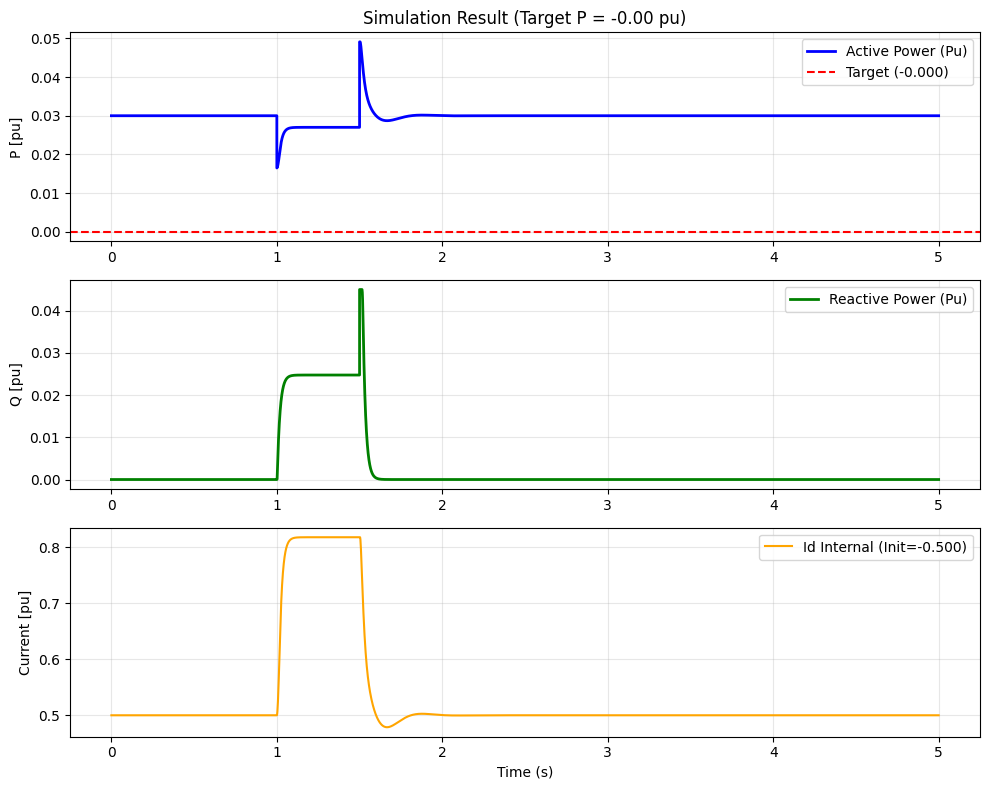

In [7]:
# Cell 7: Visualization and Verification of Flat Start
if 'dynamic_res_file' in locals() and dynamic_res_file and os.path.exists(dynamic_res_file):
    print(f"[INFO] Plotting results from {dynamic_res_file}...")
    df_dyn = pd.read_csv(dynamic_res_file)
    
    plt.figure(figsize=(10, 8))
    
    # 1. Active Power Plot
    plt.subplot(3, 1, 1)
    # Search for P injection column (PInjPu or terminal.P)
    p_col = next((c for c in df_dyn.columns if "PInjPu" in c or "terminal.P" in c), None)
    
    if p_col:
        plt.plot(df_dyn["time"], df_dyn[p_col], label="Active Power (Pu)", color='blue', linewidth=2)
        plt.axhline(y=p0_pu, color='r', linestyle='--', label=f"Target ({p0_pu:.3f})")
        plt.ylabel("P [pu]")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.title(f"Simulation Result (Target P = {p0_pu:.2f} pu)")
    else:
        plt.title("Error: Could not find Active Power column")

    # 2. Reactive Power Plot
    plt.subplot(3, 1, 2)
    q_col = next((c for c in df_dyn.columns if "QInjPu" in c or "terminal.Q" in c), None)
    if q_col:
        plt.plot(df_dyn["time"], df_dyn[q_col], label="Reactive Power (Pu)", color='green', linewidth=2)
        plt.ylabel("Q [pu]")
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, "Reactive Power Data Not Found", ha='center')
        
    # 3. Internal Current Id Plot
    plt.subplot(3, 1, 3)
    # We look for '.idPu' associated with the BESS instance
    id_col = next((c for c in df_dyn.columns if ".idPu" in c and "BESS" in c), None)
    
    if id_col:
         plt.plot(df_dyn["time"], df_dyn[id_col], label=f"Id Internal (Init={id0_val:.3f})", color='orange')
         plt.ylabel("Current [pu]")
         plt.legend() # FIX: Moved inside the 'if' to avoid Warnings if plot is empty
         plt.grid(True, alpha=0.3)
    else:
         print(f"[WARN] Could not find 'idPu' column in results. Available columns: {len(df_dyn.columns)}")
         plt.text(0.5, 0.5, "Internal State 'idPu' Not Found in CSV", ha='center')
    
    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()
else:
    print("[ERROR] No result file found to plot.")